# 📌 Importing essential libraries


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# 📌 Loading the dataset
### This line reads the healthcare dataset from a CSV file and stores it in a Pandas DataFrame.


In [5]:
data_df = pd.read_csv("healthcare_dataset.csv")

# 📌 Displaying a random sample of 5 rows  
### This helps to get a quick look at different parts of the dataset.


In [6]:
data_df.sample(10)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
24612,bARbARA BURkE,48,Female,AB-,Obesity,2020-01-18,Michael Fernandez,Horton-Brewer,UnitedHealthcare,7774.894689,383,Emergency,2020-02-14,Penicillin,Abnormal
4978,JUlIaN MAcDoNAlD,81,Male,B-,Obesity,2023-05-31,Danielle Bell,Cooper-Jones,Aetna,31128.431114,318,Elective,2023-06-18,Penicillin,Inconclusive
48923,miranda cRAwForD,38,Female,A+,Diabetes,2020-05-24,Jenna Bishop,"Simmons Gallagher, Williamson and",Medicare,8391.236533,242,Emergency,2020-05-29,Ibuprofen,Normal
33223,micHAEl RUSsElL,24,Male,AB+,Arthritis,2019-08-05,John Morrison,"Miller, Richardson and Craig",UnitedHealthcare,37046.046965,218,Urgent,2019-08-20,Aspirin,Abnormal
2593,vIctoRIA JACKson,41,Female,B-,Hypertension,2023-09-26,Evan Davis,Edwards-Johnson,Aetna,38244.863680,131,Emergency,2023-10-23,Paracetamol,Abnormal
36140,ALlIsON FlOReS,48,Male,AB+,Cancer,2019-11-14,John Fleming,"Gallegos Anderson, and Cole",Blue Cross,15111.310443,172,Elective,2019-11-22,Penicillin,Inconclusive
40461,tIMoTHy niXOn,18,Male,O+,Obesity,2021-01-13,Paul Crawford,Group Herman,UnitedHealthcare,15585.122861,480,Elective,2021-01-23,Paracetamol,Normal
43763,JOe pEterSON,63,Male,O+,Arthritis,2023-11-03,Patrick Fernandez,LLC Wells,UnitedHealthcare,34916.921221,315,Emergency,2023-11-07,Ibuprofen,Normal
18931,eVAn aBBott,68,Male,AB+,Diabetes,2023-12-09,Gabrielle Williams,"Prince and Harris, Hernandez",UnitedHealthcare,16606.985093,317,Urgent,2023-12-25,Aspirin,Inconclusive
22939,maLLORy raMirEZ,37,Female,A+,Diabetes,2021-01-24,Jay Clay,"Johnson Bailey, and Abbott",Blue Cross,4624.498155,130,Emergency,2021-02-17,Aspirin,Abnormal


In [7]:
data_df.shape

(55500, 15)

# 📌 Summary Function for DataFrames  
### This function provides a detailed summary of a given DataFrame, including:
#### - Data shape (number of rows and columns)  
#### - Data types of each column  
#### - Number and percentage of missing values  
#### - Number of unique values per column  
#### - Top occurring value and its frequency  
#### - Minimum, maximum, mean, and standard deviation for numerical columns  
#### - The first three values from the dataset for quick inspection  
### The summary is returned as a styled DataFrame for better readability.


In [8]:
def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['data type'])
    summ['#missing'] = df.isnull().sum().values 
    summ['%missing'] = df.isnull().sum().values / len(df) * 100
    summ['#unique'] = df.nunique().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['top'] = desc['top'].values
    summ['freq'] = desc['freq'].values
    summ['min'] = desc['min'].values
    summ['max'] = desc['max'].values
    summ['average'] = desc['mean'].values
    summ['standard_deviation'] = desc['std'].values
    summ['first value'] = df.loc[0].values
    summ['second value'] = df.loc[1].values
    summ['third value'] = df.loc[2].values
    
    return summ.style.background_gradient(cmap='YlOrBr')

In [9]:
summary(data_df)

data shape: (55500, 15)


,data type,#missing,%missing,#unique,top,freq,min,max,average,standard_deviation,first value,second value,third value
Name,object,0,0.000000,49992,DAvId muNoZ,3,nan,nan,nan,nan,Bobby JacksOn,LesLie TErRy,DaNnY sMitH
Age,int64,0,0.000000,77,nan,nan,13.000000,89.000000,51.539459,19.602454,30,62,76
Gender,object,0,0.000000,2,Male,27774,nan,nan,nan,nan,Male,Male,Female
Blood Type,object,0,0.000000,8,A-,6969,nan,nan,nan,nan,B-,A+,A-
Medical Condition,object,0,0.000000,6,Arthritis,9308,nan,nan,nan,nan,Cancer,Obesity,Obesity
Date of Admission,object,0,0.000000,1827,2024-03-16,50,nan,nan,nan,nan,2024-01-31,2019-08-20,2022-09-22
Doctor,object,0,0.000000,40341,Michael Smith,27,nan,nan,nan,nan,Matthew Smith,Samantha Davies,Tiffany Mitchell
Hospital,object,0,0.000000,39876,LLC Smith,44,nan,nan,nan,nan,Sons and Miller,Kim Inc,Cook PLC
Insurance Provider,object,0,0.000000,5,Cigna,11249,nan,nan,nan,nan,Blue Cross,Medicare,Aetna
Billing Amount,float64,0,0.000000,50000,nan,nan,-2008.492140,52764.276736,25539.316097,14211.454431,18856.281306,33643.327287,27955.096079


# 📌 Checking for Duplicate Rows  
### This code calculates the total number of duplicate rows in the dataset.  
### Duplicate rows can affect data quality and should be handled appropriately.


In [10]:
duplicates = data_df.duplicated().sum()
duplicates

np.int64(534)

# 📌 Removing Duplicate Rows  
This code removes all duplicate rows from the dataset. <br>  
Duplicate rows can lead to misleading analysis, so cleaning them is essential.


In [11]:
data_df = data_df.drop_duplicates()

In [12]:
duplicates = data_df.duplicated().sum()
duplicates

np.int64(0)

In [13]:
data_df.shape

(54966, 15)

# 📅 Formatting Date Columns 🕒  
### 🔹 Why is this important?  
Converting the **Date of Admission** and **Discharge Date** columns to `datetime` format ensures:  
✔️ **Accurate date-based operations**  
✔️ **Easy calculations & filtering**  
✔️ **Better time-series analysis**  

---


In [14]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood Type          54966 non-null  object 
 4   Medical Condition   54966 non-null  object 
 5   Date of Admission   54966 non-null  object 
 6   Doctor              54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Insurance Provider  54966 non-null  object 
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  object 
 12  Discharge Date      54966 non-null  object 
 13  Medication          54966 non-null  object 
 14  Test Results        54966 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.7+ MB


# حساب مده الاقامه ف المستشفي

# ⏳ Calculating Hospital Stay Duration  
### 🔹 What does this do?  
We calculate the **duration of stay** for each patient by subtracting the **Date of Admission** from the **Discharge Date**.  

✔️ Helps analyze **average hospital stay**  
✔️ Useful for **resource allocation & patient flow analysis**  
✔️ Enables **trend detection** in hospital admissions  

---


In [15]:
# Feature engineering: Convert 'Date of Admission' to datetime and extract features
data_df['Date of Admission'] = pd.to_datetime(data_df['Date of Admission'])
data_df['Discharge Date'] = pd.to_datetime(data_df['Discharge Date'])


In [16]:
data_df.sample(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
9721,pAmELA McgUIRe,20,Male,B-,Arthritis,2023-09-12,Roberto Marsh,Walker PLC,UnitedHealthcare,41289.747706,103,Elective,2023-09-24,Aspirin,Normal
17341,JESSica hOwaRd,30,Female,A-,Diabetes,2019-11-09,Rebecca Brown,LLC Miller,Blue Cross,2889.219403,231,Elective,2019-12-05,Lipitor,Normal
21589,MichAEL MUrRay,54,Female,O+,Arthritis,2019-11-14,Natalie Nash,Inc Miller,Blue Cross,18524.208042,343,Elective,2019-12-14,Aspirin,Inconclusive
26989,JaSmInE MORRiSon,76,Female,A+,Arthritis,2024-05-02,Michael Payne,"and Lawson Meyer Armstrong,",Medicare,24522.511813,394,Elective,2024-05-08,Aspirin,Abnormal
15391,joHN brADlEY Dds,77,Male,B-,Hypertension,2022-02-24,Jose Herrera,Li-Bowman,UnitedHealthcare,38187.137779,237,Elective,2022-03-17,Ibuprofen,Abnormal


In [17]:
Gender = data_df['Gender'].value_counts()
Gender

Gender
Male      27496
Female    27470
Name: count, dtype: int64

# 📊 Age & Gender Distribution  
### 🔍 Why is this analysis important?  
Understanding the **age distribution** and **gender ratio** helps in:  

✔️ **Identifying the age groups** most affected  
✔️ **Analyzing gender disparities** in hospital admissions  
✔️ **Optimizing resource allocation** for different demographics  

---


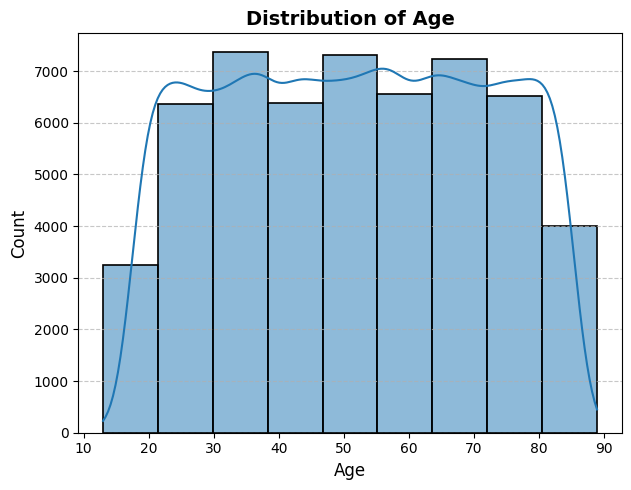

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data_df['Age'], bins=9, kde=True, color='#1f77b4', edgecolor='black', linewidth=1.2)
plt.title("Distribution of Age", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

fig = px.sunburst(
    data_df, 
    path=['Gender'], 
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(textinfo="label+percent parent")
fig.update_layout(
    title={
        'text': "Patient's Gender Distribution",
        'font': {'size': 20, 'family': 'Arial'}
    },
    width=600,
    height=600
)


plt.tight_layout() 
plt.show()
fig.show()  

# 🔍 Insights from the Chart  

## 📊 General Age Distribution  
- The data is **evenly distributed** across age groups from **20 to 80 years**, indicating no significant bias toward a specific age group.  
- There is a **notable increase** in the number of patients in the **30 - 70 years** age range, meaning this group is the most frequent visitors to the hospital.  

## 📉 Decrease in Younger and Older Age Groups  
- **Patients under 20 years** and **over 80 years** have relatively lower numbers, which might indicate:  
  - 🧒 **Children & Teenagers:** Require **less frequent hospitalization** compared to adults.  
  - 👴 **Elderly Patients:** Might have **lower admission rates** or different treatment pathways (e.g., home care).  


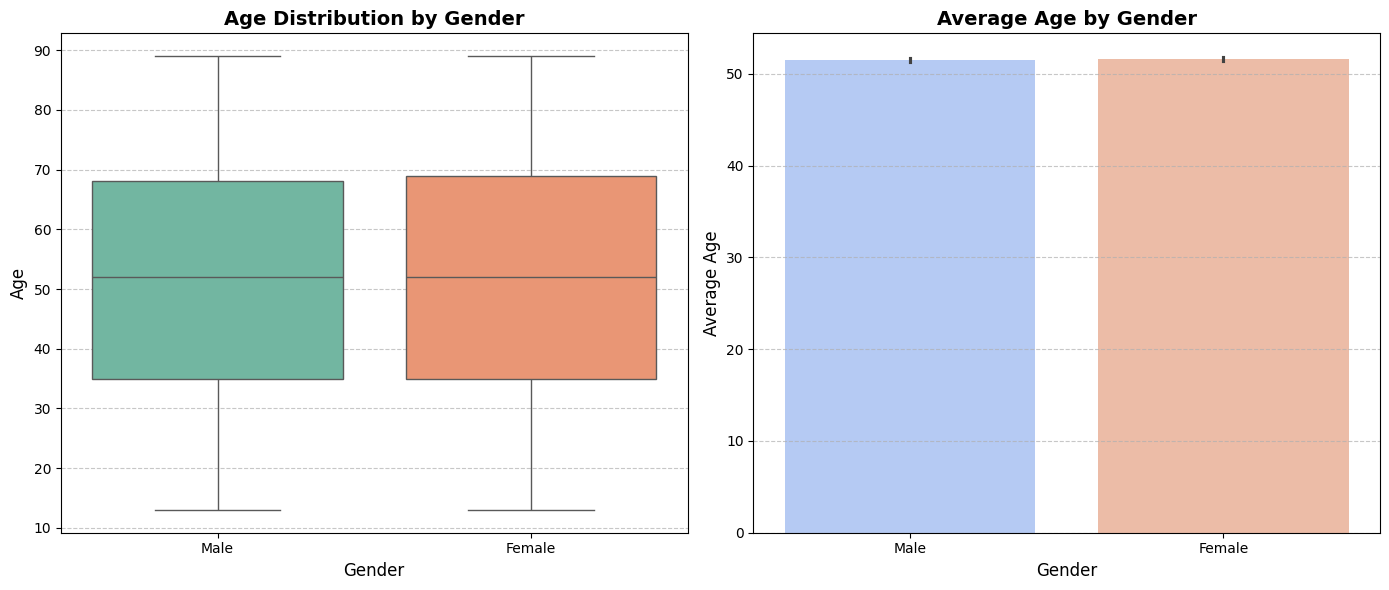

In [19]:
plt.figure(figsize=(14, 6))

# Boxplot لتوضيح توزيع العمر بين الذكور والإناث
plt.subplot(1, 2, 1)
sns.boxplot(x="Gender", y="Age", data=data_df, palette="Set2")
plt.title("Age Distribution by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Barplot لعرض متوسط العمر لكل جنس
plt.subplot(1, 2, 2)
sns.barplot(x="Gender", y="Age", data=data_df, estimator=lambda x: x.mean(), palette="coolwarm")
plt.title("Average Age by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Age", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


# 🔍 Insights from the Graphs

## 📊 **Age Distribution by Gender (Left - Boxplot)**
- The age distribution is **similar for both males and females**, indicating no significant difference in age groups.
- The **median age** for both genders is around **50 years**.
- There is a **wide spread of ages**, with some **outliers** in the younger and older age groups.

## 📉 **Average Age by Gender (Right - Barplot)**
- The **average age is nearly identical** for both males and females (~50 years).
- No significant difference in average age suggests a **balanced age distribution** across genders.


# -------------------------------------------------------------------

# 🩸 **Blood Type Distribution Analysis**  

## 📌 **What Does the Code Do?**  
This code processes a dataset to determine the frequency of different blood types. It counts occurrences and structures the data into a readable format.


In [20]:
Boold_df = data_df['Blood Type'].value_counts().reset_index()
Boold_df.columns = ['Blood Type', 'Count']  # تسمية الأعمدة
print(Boold_df)


  Blood Type  Count
0         A-   6898
1         A+   6896
2         B+   6885
3        AB+   6882
4        AB-   6874
5         B-   6872
6         O+   6855
7         O-   6804


In [22]:
import plotly.express as px
import pandas as pd

# حساب التوزيع
blood_counts = data_df['Blood Type'].value_counts().reset_index()
blood_counts.columns = ['Blood Type', 'Count']

# الرسم
fig = px.bar(
    blood_counts,
    x='Blood Type',
    y='Count',
    color='Blood Type',
    title="Distribution of Blood Types",
    labels={'Blood Type': 'Blood Type', 'Count': 'Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    xaxis_title="Blood Type",
    yaxis_title="Count",
    template="plotly_white"
)

fig.show()


In [23]:
import plotly.express as px

# رسم المخطط الدائري لفصائل الدم
fig = px.pie(data_df, names='Blood Type', 
             title="Distribution of Blood Types", 
             hole=0.3,  # يعطي شكل "Donut"
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textinfo="percent+label", pull=[0.05]*len(data_df['Blood Type'].unique()))  
fig.show()


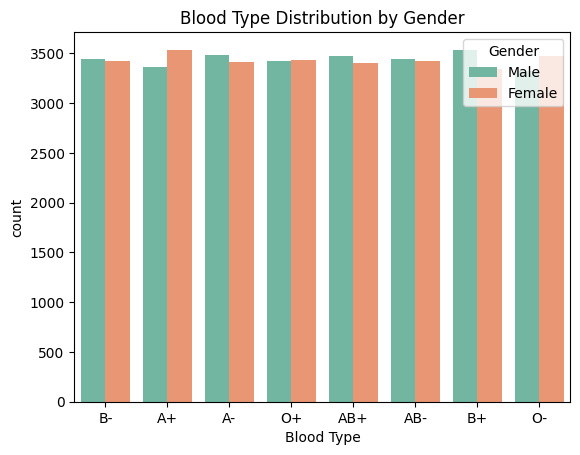

In [24]:
sns.countplot(x='Blood Type', hue='Gender', data=data_df, palette='Set2')
plt.title("Blood Type Distribution by Gender")
plt.show()


# Medical Condition

In [25]:
Medical_Condition = data_df['Medical Condition'].value_counts().reset_index()
Medical_Condition.columns = ['Medical Condition', 'Count']  
print(Medical_Condition)

  Medical Condition  Count
0         Arthritis   9218
1          Diabetes   9216
2      Hypertension   9151
3           Obesity   9146
4            Cancer   9140
5            Asthma   9095


# 📊 Insights from Medical Condition Data  

## 🔹 1. Chronic Diseases Are Almost Equally Common  
- The **differences in case counts** for each disease are **minimal**, indicating that all these conditions are **almost equally prevalent**.  
- The highest number of cases is **Arthritis (9,218 cases)**, followed closely by **Diabetes (9,216 cases)**.  
- The lowest number of cases is **Asthma (9,095 cases)**, yet it remains very close to the other conditions.  

🔍 This suggests that **no single condition dominates**, highlighting the need for **equal attention** to all these chronic diseases.  


In [26]:
import plotly.express as px

# رسم المخطط الدائري لفصائل الدم
fig = px.pie(data_df, names='Medical Condition', 
             title="Distribution of Medical Condition", 
             hole=0.3,  # يعطي شكل "Donut"
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textinfo="percent+label", pull=[0.05]*len(data_df['Medical Condition'].unique()))  
fig.show()

In [27]:
# حساب عدد الحالات لكل فصيلة دم
condition_blood = data_df.groupby(['Blood Type', 'Medical Condition']).size().unstack()

# عرض توزيع الحالات لكل فصيلة دم
print(condition_blood)


Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Blood Type                                                                   
A+                      1107    1124    1171      1201          1123     1170
A-                      1144    1162    1124      1154          1186     1128
AB+                     1124    1173    1100      1165          1204     1116
AB-                     1179    1123    1186      1132          1108     1146
B+                      1191    1104    1186      1180          1087     1137
B-                      1152    1108    1131      1136          1163     1182
O+                      1186    1162    1098      1142          1145     1122
O-                      1135    1139    1144      1106          1135     1145


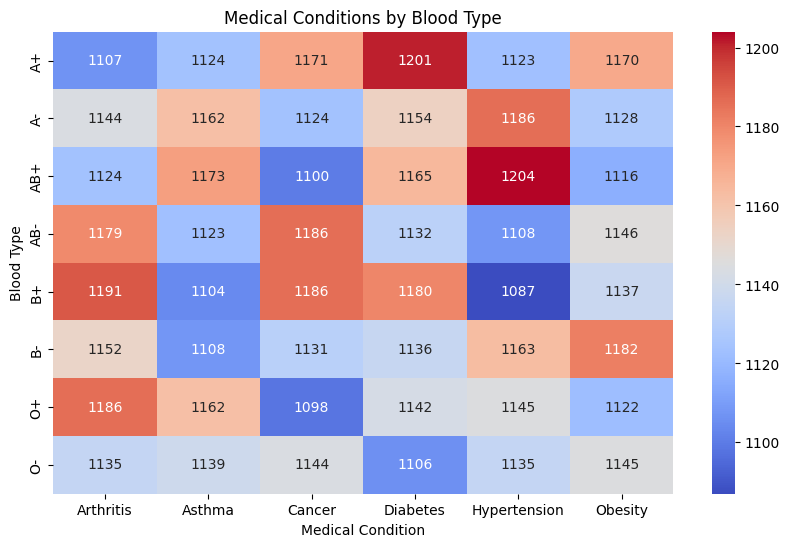

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(condition_blood, annot=True, cmap='coolwarm', fmt='d')
plt.title("Medical Conditions by Blood Type")
plt.xlabel("Medical Condition")
plt.ylabel("Blood Type")
plt.show()


In [29]:
# Group by 'Blood Type' and 'Medical Condition' and calculate the count for each combination
grouped_df = data_df.groupby(['Blood Type', 'Medical Condition']).size().reset_index(name='Count')

# Plot using Plotly Express
fig = px.bar(grouped_df, x='Blood Type', y='Count', color='Medical Condition', barmode='group',
             title='Patient Count by Blood Type and Medical Condition',
             labels={'Count': 'Patient Count', 'Blood Type': 'Blood Type', 'Medical Condition': 'Medical Condition'})
fig.show()

# 📊 Insights from Medical Condition Data  

## 🔹 1. Prevalence of Chronic Diseases  
The data reveals that chronic diseases have a **similar prevalence rate** across the dataset.  

- The highest recorded cases are for **Arthritis (9,218 cases)**, closely followed by **Diabetes (9,216 cases)**.  
- The lowest recorded cases are for **Asthma (9,095 cases)**, but the difference is minimal compared to other conditions.  
- The variation in case numbers is **insignificant**, suggesting that these medical conditions are equally common in the population.  

## 📌 Key Takeaways  
✅ The distribution of medical conditions is **evenly spread**, indicating a balanced dataset.  
✅ No single condition dominates significantly over others.  
✅ Further analysis can explore demographic and environmental factors influencing these conditions.  


In [30]:
condition_gender = data_df.groupby(['Gender', 'Medical Condition']).size().unstack()
print(condition_gender)


Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Gender                                                                       
Female                  4642    4511    4566      4609          4569     4573
Male                    4576    4584    4574      4607          4582     4573


<Figure size 1000x600 with 0 Axes>

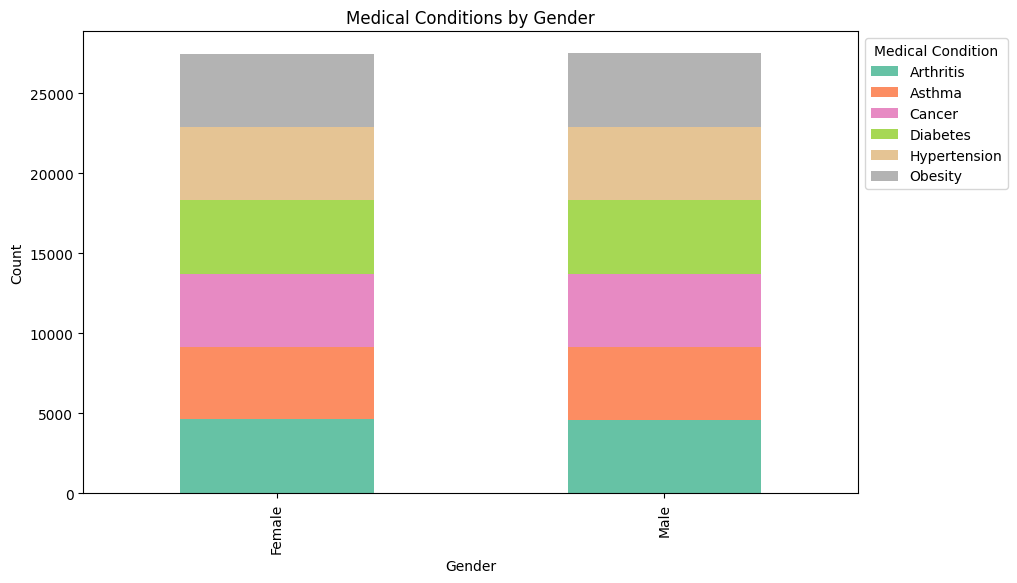

In [31]:
plt.figure(figsize=(10,6))
condition_gender.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
plt.title("Medical Conditions by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Medical Condition", bbox_to_anchor=(1,1))
plt.show()


In [32]:
data_df.sample(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
27775,racHeL rObertSon,46,Male,B+,Arthritis,2023-10-16,Brandon Gutierrez,Christian-Chavez,Medicare,23069.918150,291,Emergency,2023-11-08,Paracetamol,Normal
44097,vICTorIa ellIS,76,Male,B-,Cancer,2023-11-24,Mark Brown,Lynch-Joseph,Aetna,33744.796635,498,Emergency,2023-12-23,Aspirin,Inconclusive
4357,aMY CaRDENas,39,Male,A+,Diabetes,2020-04-30,Christopher Henderson,"Stevens Turner, and Smith",Blue Cross,15597.603315,355,Elective,2020-05-01,Penicillin,Normal
28093,mIchAeL TuCker,44,Male,B+,Asthma,2021-02-21,Kelly Johnson,"Jones, Gallegos and Guerrero",Medicare,11908.460479,401,Urgent,2021-03-05,Penicillin,Inconclusive
38011,BruCE evAns,52,Male,B-,Diabetes,2023-03-22,George Stone,"Bruce Harris and Robinson,",Medicare,17277.260833,190,Emergency,2023-04-18,Paracetamol,Abnormal


# Doctor 

# ❓ Analytical Question About the Code  
**Which doctors handle the most patient claims?**  
- Who are the top 5 doctors with the highest number of claims?  

In [33]:
Doctor_counts = data_df["Doctor"].value_counts()
print("Top Doctor:\n", Doctor_counts.head())

Top Doctor:
 Doctor
Michael Smith      27
John Smith         22
Robert Smith       21
Michael Johnson    20
James Smith        20
Name: count, dtype: int64


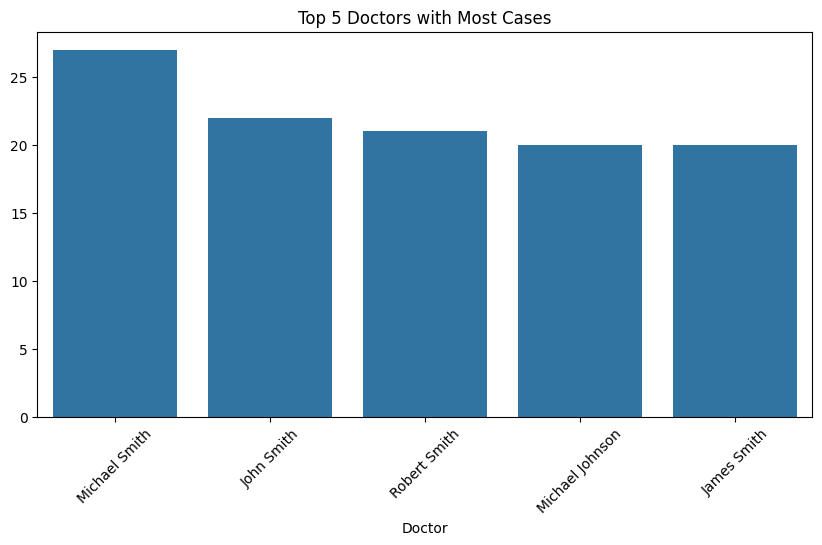

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(x=Doctor_counts.index[:5], y=Doctor_counts.values[:5])
plt.xticks(rotation=45)
plt.title("Top 5 Doctors with Most Cases")
plt.show()

### 📊 Insights from the "Top 5 Doctors with Most Cases" Chart  

1️⃣ **Michael Smith has the highest number of cases**  
- His bar is the tallest, indicating that he handles the most patients.  
- This could be due to his extensive experience, specialization in a common disease, or working in a major hospital.  

2️⃣ **Close number of cases among other doctors**  
- The other four doctors have very similar case counts.  
- This suggests a balanced distribution of patients among them, which may reflect good workload management.  


# Hospital

# ❓ Analytical Question About the Code  
**Which hospitals have the highest number of claims?**  
- What are the top 5 hospitals based on claim frequency?  


In [35]:
hospital_counts = data_df['Hospital'].value_counts()
print("Top Hospitals:\n", hospital_counts.head())

Top Hospitals:
 Hospital
LLC Smith      44
Ltd Smith      39
Smith Ltd      37
Johnson PLC    37
Smith Group    36
Name: count, dtype: int64


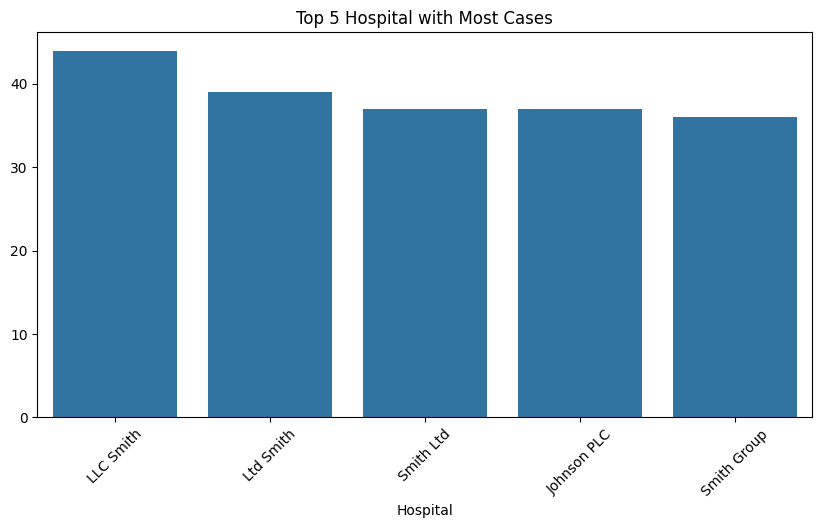

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(x=hospital_counts.index[:5], y=hospital_counts.values[:5])
plt.xticks(rotation=45)
plt.title("Top 5 Hospital with Most Cases")
plt.show()

### 📊 Insights from the "Top 5 Hospitals with Most Cases" Chart  

1️⃣ **LLC Smith has the highest number of cases**  
- Its bar is the tallest, indicating that it handles the most patients.  
- This could be due to its size, reputation, or specialization in high-demand medical services.  

2️⃣ **Close case numbers among other hospitals**  
- The remaining four hospitals have very similar case counts.  
- This suggests a relatively even distribution of patient load among them, reflecting a balanced healthcare system.  


# ------------------------------------------------------------

# ❓ Analytical Question About the Code  
**How many unique insurance providers are present in the dataset?**  
- What is the total number of distinct insurance providers?  



In [37]:
Num_provider = data_df["Insurance Provider"].nunique()
Num_provider

5

In [38]:
Provider_counts = data_df['Insurance Provider'].value_counts()
print("Insurance Provider:\n", Provider_counts.head())

Insurance Provider:
 Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64


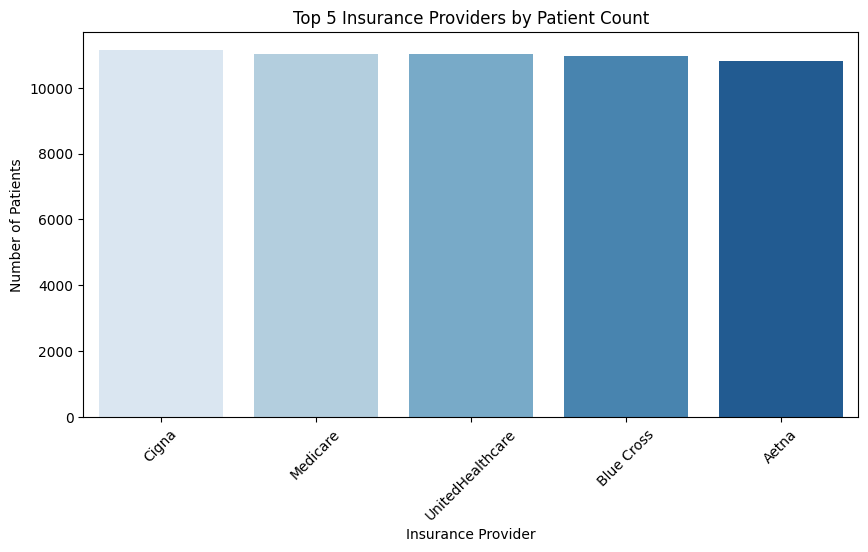

In [39]:
plt.figure(figsize=(10,5))
sns.barplot(x=Provider_counts.index[:5], y=Provider_counts.values[:5], palette="Blues")
plt.xticks(rotation=45)
plt.title("Top 5 Insurance Providers by Patient Count")
plt.xlabel("Insurance Provider")
plt.ylabel("Number of Patients")
plt.show()

### 🏥 Insights from the "Top Insurance Providers by Case Count"  

1️⃣ **Cigna has the highest number of cases**  
- With **11,139 cases**, Cigna leads the list, suggesting it is the most widely used insurance provider among patients.  

2️⃣ **Close competition among top providers**  
- Medicare, UnitedHealthcare, Blue Cross, and Aetna all have similar case counts, with differences of only a few hundred cases.  
- This indicates a well-distributed reliance on multiple insurance providers rather than dominance by one company.  


# Billing Amount

In [40]:
Doctor_counts = data_df["Billing Amount"].value_counts()
print("Billing Amount:\n", Doctor_counts.head())

Billing Amount:
 Billing Amount
43517.572536    2
45641.509219    2
39297.224989    2
11726.626932    2
14238.317814    2
Name: count, dtype: int64


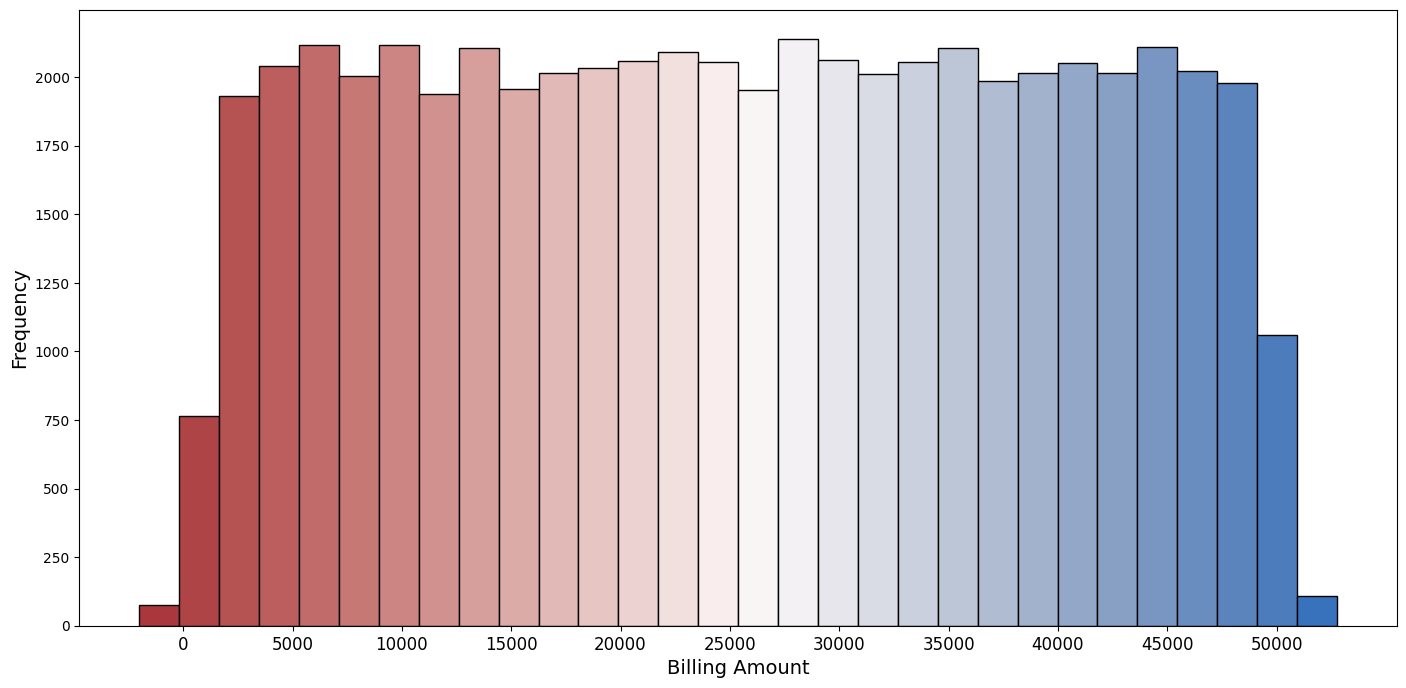

In [41]:
plt.figure(figsize=(17, 8))
cmap = plt.get_cmap('vlag_r')
n, bins, patches = plt.hist(data_df["Billing Amount"] , bins=30, edgecolor='black')
norm = plt.Normalize(vmin=min(data_df["Billing Amount"]), vmax=max(data_df["Billing Amount"]))
for bin, patch in zip(bins, patches):
    color = cmap(norm(bin))
    patch.set_facecolor(color)
ticks = np.arange(0, data_df["Billing Amount"].max(), step=5000)
plt.xticks(ticks=ticks, fontsize=12)
plt.xlabel("Billing Amount", fontsize=14)
plt.ylabel("Frequency", fontsize=14)


plt.show()

# ❓ Analytical Question About the Code  
**What are the top 5 highest billing amounts in the dataset?**  
- Which claims have the highest billing amounts?  


In [42]:
top_3_bills = data_df['Billing Amount'].nlargest(5)
print(top_3_bills)

36349    52764.276736
34613    52373.032374
51313    52373.032374
5735     52271.663747
7088     52211.852966
Name: Billing Amount, dtype: float64


### 📈 Insights from "Top 5 Highest Billing Amounts"  

1️⃣ **The highest billing amount recorded is $52,764**  
- This could indicate a **high-cost medical procedure** or **long-term patient care**.  

2️⃣ **Two billing amounts are identical ($52,373)**  
- Possible reasons:
  - Standardized pricing for specific treatments.
  - Repeated medical services billed at the same rate.  

3️⃣ **Small variation in the top 5 values**  
- The difference between the highest ($52,764) and lowest ($52,211) among the top 5 bills is just **$553**.  
- This suggests that **very high medical bills tend to cluster within a close range**.  


# ----------------------------------------------------------------------

# ❓ Analytical Question About the Code  
**Which insurance provider has the highest average billing amount?**  
- How does the average billing amount vary across different providers?  
- Are there significant differences between providers in terms of billing amounts?  


In [43]:
insurance_billing_avg = data_df.groupby("Insurance Provider")["Billing Amount"].mean().sort_values(ascending=False)
print("Average Billing Amount per Insurance Provider:\n", insurance_billing_avg)

Average Billing Amount per Insurance Provider:
 Insurance Provider
Medicare            25628.320208
Blue Cross          25603.460603
Aetna               25549.689648
Cigna               25525.998670
UnitedHealthcare    25414.506208
Name: Billing Amount, dtype: float64


In [44]:
import plotly.express as px

# رسم المخطط الدائري لفصائل الدم
fig = px.pie(data_df, names='Insurance Provider', 
             title="Distribution of Insurance Provider", 
             hole=0.3,  # يعطي شكل "Donut"
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textinfo="percent+label", pull=[0.05]*len(data_df['Insurance Provider'].unique()))  
fig.show()

### 💰 Insights from "Average Billing Amount per Insurance Provider"  

1️⃣ **Medicare has the highest average billing amount**  
- With an average billing of **$25,628**, Medicare leads the list, suggesting that patients under this provider might require more expensive treatments or services.  

2️⃣ **Close range of billing amounts among providers**  
- The difference between the highest (Medicare: $25,628) and lowest (UnitedHealthcare: $25,414) is relatively small (~$214).  
- This indicates a **consistent billing trend** across insurance providers, suggesting standardized pricing for medical services.  


# --------------------------------------------------

# ❓ Analytical Question 
**Which insurance provider has the highest billing amount?**  
- Is there a significant difference between the highest claims for each provider?  
- Is there any pattern in the distribution of values among different insurance providers?  


In [45]:
highest_bill_per_insurance = data_df.loc[data_df.groupby("Insurance Provider")["Billing Amount"].idxmax()]

# عرض النتيجة
print(highest_bill_per_insurance[["Insurance Provider", "Billing Amount"]])

      Insurance Provider  Billing Amount
7088               Aetna    52211.852966
36349         Blue Cross    52764.276736
6663               Cigna    52170.036854
13868           Medicare    52092.669896
34613   UnitedHealthcare    52373.032374


### 💡 Insights from "Highest Billing Amount per Insurance Provider"  

1️⃣ **Blue Cross recorded the highest individual bill of $52,764**  
   - This could indicate coverage for **expensive treatments or specialized medical care**.  

2️⃣ **The highest billing amounts across providers are relatively close**  
   - The range spans from **$52,211 (Aetna) to $52,764 (Blue Cross)**.  
   - This suggests that **high-end medical expenses remain within a certain threshold**, regardless of the provider.  

3️⃣ **UnitedHealthcare has a high billing amount ($52,373), close to Blue Cross**  
   - Possible reasons:
     - Similar patient demographics.
     - Coverage for similar medical procedures.  

4️⃣ **Cigna, Medicare, and Aetna also show high billing amounts ($52,170 - $52,211)**  
   - **No extreme outliers** indicate that insurance providers **generally cap high medical expenses at a similar range**.  


In [46]:
data_df.sample(5)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
30957,LAura wyaTT,38,Male,AB+,Asthma,2024-01-11,Kimberly Adams,Price PLC,Aetna,25507.123575,435,Urgent,2024-02-08,Ibuprofen,Normal
40727,kElLy fRYe,18,Female,A+,Cancer,2021-11-28,Jillian Taylor,"Lopez Aguirre, Fisher and",Cigna,7896.719789,226,Urgent,2021-12-14,Ibuprofen,Abnormal
23791,taRA SMitH,24,Female,A-,Diabetes,2024-02-05,Lori Nichols,Moreno-Walsh,Blue Cross,46240.534084,410,Elective,2024-02-06,Paracetamol,Normal
26814,BoNnIE Lewis,32,Male,AB-,Asthma,2023-07-10,Anthony Owens,Martinez Inc,Medicare,25094.228652,265,Urgent,2023-07-15,Lipitor,Normal
19645,JOANn tHOmpsOn,83,Male,AB-,Hypertension,2023-09-08,Stephanie Chavez,"Orozco Vazquez White, and",Cigna,24549.236738,482,Urgent,2023-10-02,Paracetamol,Inconclusive


# Admission Type

In [47]:
Admission_Type = data_df['Admission Type'].value_counts()
Admission_Type

Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

In [48]:
import plotly.express as px

fig = px.pie(data_df, names='Admission Type', 
             title="Distribution of Admission Type", 
             hole=0.3,  
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textinfo="percent+label", pull=[0.05]*len(data_df['Admission Type'].unique()))  
fig.show()

In [49]:
data_df.groupby('Admission Type')['Age'].mean()


Admission Type
Elective     51.435013
Emergency    51.539830
Urgent       51.631233
Name: Age, dtype: float64

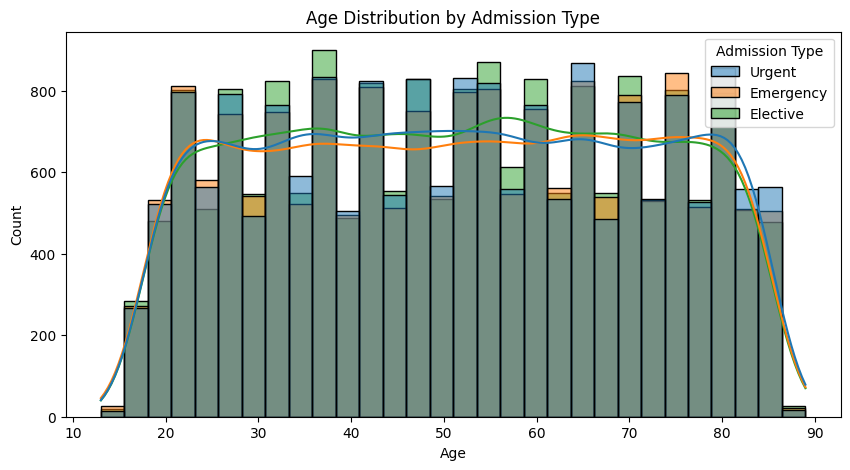

In [50]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data_df, x='Age', hue='Admission Type', kde=True, bins=30)
plt.title("Age Distribution by Admission Type")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### 📊 Analysis of the "Age Distribution by Admission Type" Chart

- There is a decrease in the number of patients under **20 years old** and over **80 years old**.  
- ✅ Most patients are between **20 and 80 years old**.  
- ✅ **Admission type is not significantly affected by age**, as all types are distributed similarly across different age groups.  
- ✅ **Elective admissions appear to be more common among older age groups** compared to emergency admissions.  


#  -------------------------------------------------

# Group by 'Admission Type' and 'Medical Condition'

In [51]:
# Group by 'Admission Type' and 'Medical Condition' and calculate the count for each combination
grouped_df = data_df.groupby(['Admission Type', 'Medical Condition']).size().reset_index(name='Count')

# Plot using Plotly Express
fig = px.bar(grouped_df, x='Admission Type', y='Count', color='Medical Condition', barmode='group',
             title='Patient Count by Admission Type and Medical Condition',
             labels={'Count': 'Patient Count', 'Admission Type': 'Admission Type', 'Medical Condition': 'Medical Condition'})
fig.show()

#   Group by 'Admission Type' and 'Gender'

In [52]:
# Group by 'Admission Type' and 'Gender' and calculate the count for each combination
grouped_df = data_df.groupby(['Admission Type', 'Gender']).size().reset_index(name='Count')

# Plot using Plotly Express
fig = px.bar(grouped_df, x='Admission Type', y='Count', color='Gender', barmode='group',
             title='Patient Count by Admission Type and Gender',
             labels={'Count': 'Patient Count', 'Admission Type': 'Admission Type', 'Gender': 'Gender'})
fig.show()

# Discharge Date  و Date of Admission

In [53]:
import pandas as pd


top_5_days = data_df['Date of Admission'].value_counts().head().reset_index()
top_5_days.columns = ['Date', 'Count']

top_5_months = data_df['Date of Admission'].dt.to_period('M').value_counts().head().reset_index()
top_5_months.columns = ['Month', 'Count']


top_5_years = data_df['Date of Admission'].dt.to_period('Y').value_counts().head().reset_index()
top_5_years.columns = ['Year', 'Count']


print("Top 5 Days (Date of Admission):")
print(top_5_days.to_string(index=False))

print("\nTop 5 Months (Date of Admission):")
print(top_5_months.to_string(index=False))

print("\nTop 5 Years (Date of Admission):")
print(top_5_years.to_string(index=False))


Top 5 Days (Date of Admission):
      Date  Count
2024-03-16     50
2020-10-22     49
2021-12-28     48
2021-01-03     47
2022-07-24     47

Top 5 Months (Date of Admission):
  Month  Count
2020-08   1003
2020-07   1000
2019-10    993
2019-08    985
2020-05    970

Top 5 Years (Date of Admission):
Year  Count
2020  11172
2023  10936
2022  10915
2021  10816
2019   7300


# Medication	

In [54]:
num_of_value = data_df['Medication'].value_counts().head()
num_of_value.columns = [ 'Count']
num_of_value

Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64

In [55]:
import plotly.express as px

fig = px.pie(data_df, names='Medication', 
             title="Distribution of Medication", 
             hole=0.3,  
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textinfo="percent+label", pull=[0.05]*len(data_df['Medication'].unique()))  
fig.show()

# Group by 'Medication' and 'Gender'

In [56]:
# Group by 'Medication' and 'Gender' and calculate the count for each combination
grouped_df = data_df.groupby(['Medication', 'Gender']).size().reset_index(name='Count')

# Plot using Plotly Express
fig = px.bar(grouped_df, x='Medication', y='Count', color='Gender', barmode='group',
             title='Medication Distribution by Gender',
             labels={'Count': 'Count', 'Medication': 'Medication', 'Gender': 'Gender'})
fig.show()

# Test Results

In [57]:
data_df['Test Results'] = data_df['Test Results'].apply(lambda x: 'Normal' if x == 'Normal' else 'Abnormal')



In [58]:
num_of_value = data_df['Test Results'].value_counts().head()
num_of_value.columns = [ 'Count']
num_of_value

Test Results
Abnormal    36635
Normal      18331
Name: count, dtype: int64

In [59]:
# Group by 'Test Results' and 'Admission Type' and calculate the count for each combination
grouped_df = data_df.groupby(['Test Results', 'Admission Type']).size().reset_index(name='Count')

# Plot using Plotly Express
fig = px.bar(grouped_df, x='Test Results', y='Count', color='Admission Type', barmode='group',
             title='Test Results Distribution by Admission Type',
             labels={'Count': 'Count', 'Test Results': 'Test Results', 'Admission Type': 'Admission Type'})
fig.show()

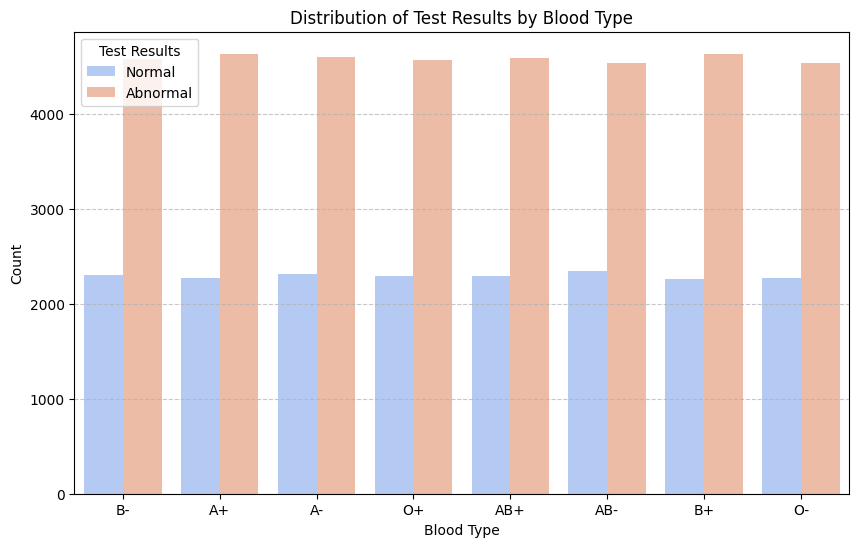

In [60]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data_df, x='Blood Type', hue='Test Results', palette='coolwarm')

plt.title("Distribution of Test Results by Blood Type")
plt.xlabel("Blood Type")
plt.ylabel("Count")
plt.legend(title="Test Results")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Test Results by Medical Condition:
Test Results       Abnormal  Normal
Medical Condition                  
Arthritis              6218    3000
Asthma                 5979    3116
Cancer                 6122    3018
Diabetes               6155    3061
Hypertension           6045    3106
Obesity                6116    3030


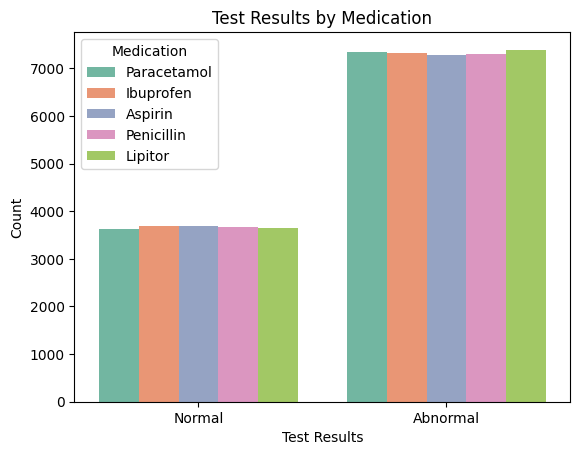

In [61]:
condition_vs_test = data_df.groupby('Medical Condition')['Test Results'].value_counts().unstack()
print("Test Results by Medical Condition:")
print(condition_vs_test)

# Visualization for Medication
sns.countplot(data=data_df, x='Test Results', hue='Medication', palette='Set2')
plt.title('Test Results by Medication')
plt.xlabel('Test Results')
plt.ylabel('Count')
plt.legend(title='Medication')
plt.show()

### Purpose
- Converts all categorical/text columns in a DataFrame into numerical labels, making the data suitable for machine learning algorithms that require numerical input.

In [62]:
data_df = data_df.drop(columns=['Date of Admission', 'Discharge Date'])

In [63]:
print(data_df.columns)

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Medication', 'Test Results'],
      dtype='object')


In [64]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

categorical_cols = []
for col in data_df.columns:
    if data_df[col].dtypes == 'object':
        categorical_cols.append(col)
for col in categorical_cols:
    data_df[col] = le.fit_transform(data_df[col])
data_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results
0,3068,30,1,5,2,26612,29933,1,18856.281306,328,2,3,1
1,15211,62,1,0,5,33648,16012,3,33643.327287,265,1,1,0
2,6476,76,0,1,5,37828,5473,0,27955.096079,205,1,0,1
3,26935,28,0,6,3,22511,12317,3,37909.782410,450,0,1,0
4,26241,43,0,2,2,21259,33598,0,14238.317814,458,2,4,0


### 1. Data Preparation (After Encoding)


In [65]:
import pandas as pd

# نفترض df هو DataFrame
df = data_df.drop(['Name', 'Doctor', 'Hospital', 'Insurance Provider'], axis=1)


In [66]:
df

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Room Number,Admission Type,Medication,Test Results
0,30,1,5,2,18856.281306,328,2,3,1
1,62,1,0,5,33643.327287,265,1,1,0
2,76,0,1,5,27955.096079,205,1,0,1
3,28,0,6,3,37909.782410,450,0,1,0
4,43,0,2,2,14238.317814,458,2,4,0
...,...,...,...,...,...,...,...,...,...
55495,42,0,6,1,2650.714952,417,0,4,0
55496,61,0,3,5,31457.797307,316,0,0,1
55497,38,0,4,4,27620.764717,347,2,1,0
55498,43,1,7,0,32451.092358,321,0,1,0


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Separate features (X) and target (y)
X = df.drop('Test Results', axis=1)  # Replace with your actual target column name
y = df['Test Results']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
X_train.columns


Index(['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Billing Amount',
       'Room Number', 'Admission Type', 'Medication'],
      dtype='object')

In [69]:
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, roc_curve, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from collections import Counter
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

### RandomForestClassifier


In [ ]:
rf = RandomForestClassifier(n_estimators= 500, max_depth = 5 ,random_state = 42).fit(X_train,y_train)
rf.score(X_test,y_test)

0.6921957431326178

In [71]:
y_pred = rf.predict(X_test)


In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.6921957431326178

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.95      0.80      7298
           1       0.66      0.18      0.28      3696

    accuracy                           0.69     10994
   macro avg       0.68      0.57      0.54     10994
weighted avg       0.68      0.69      0.63     10994


Confusion Matrix:
 [[6954  344]
 [3040  656]]


# Model saving

In [73]:
import joblib
joblib.dump(rf, 'model.pkl')


['model.pkl']

# MLflow 

In [74]:
## main
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, argparse
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Random_Forest MLflow  Hyperparameter Tuning

In [75]:
def train_model(X_train, y_train, X_test, y_test, n_estimators, max_depth, plot_name, class_weight=None):
   

    mlflow.set_experiment(f'Random_forest')
    with mlflow.start_run(run_name=f"R_F_{n_estimators}_d{max_depth}") as run:
        mlflow.set_tag('clf', 'forest') 

        clf = RandomForestClassifier(random_state=42)
        clf.fit(X_train, y_train)
        y_pred_test = clf.predict(X_test)

        # Metrics
        f1_test = f1_score(y_test, y_pred_test)
        acc_test = accuracy_score(y_test, y_pred_test)

        # Log params, metrics, and model 
        mlflow.log_params({'n_estimators': n_estimators, 'max_depth': max_depth})
        mlflow.log_metrics({'accuracy': acc_test, 'f1-score': f1_test})
        mlflow.sklearn.log_model(clf, f'{clf.__class__.__name__}')

        # Confusion matrix
        plt.figure(figsize=(10, 6))
        sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cbar=False, fmt='d', cmap='Blues')
        plt.title(f'{plot_name}')
        plt.xticks(ticks=np.arange(2) + 0.5, labels=[False, True])
        plt.yticks(ticks=np.arange(2) + 0.5, labels=[False, True])
        conf_matrix_fig = plt.gcf()
        mlflow.log_figure(figure=conf_matrix_fig, artifact_file=f'conf_matrix.png')
        plt.close()

        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_test)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        roc_fig = plt.gcf()
        mlflow.log_figure(figure=roc_fig, artifact_file=f'{plot_name}_roc_curve.png')
        plt.close()


In [76]:
train_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_estimators=500,
    max_depth=5,
    plot_name="Random Forest",
    class_weight=None
)


2025/05/10 22:13:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# Decision_Tree MLflow

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
def train_model(X_train, y_train, X_test, y_test,
                criterion, max_depth, min_samples_split,
                min_samples_leaf, plot_name, class_weight=None):

    mlflow.set_experiment(f'DecisionTree')

    with mlflow.start_run(run_name=f"D_T_{criterion}_d{max_depth}") as run:
        mlflow.set_tag('clf', 'DT') 

        # إنشاء النموذج باستخدام البارامترات المدخلة
        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight=class_weight,
            random_state=42
        )

        # تدريب النموذج
        model.fit(X_train, y_train)

        # التنبؤ
        y_pred_test = model.predict(X_test)

        # حساب المقاييس
        f1_test = f1_score(y_test, y_pred_test)
        acc_test = accuracy_score(y_test, y_pred_test)

        # تسجيل البارامترات والمقاييس
        mlflow.log_params({
            'criterion': criterion,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf,
            'class_weight': class_weight
        })
        mlflow.log_metrics({
            'accuracy': acc_test,
            'f1-score': f1_test
        })

        # تسجيل النموذج
        mlflow.sklearn.log_model(model, f'{model.__class__.__name__}')

        # مصفوفة الالتباس
        plt.figure(figsize=(10, 6))
        sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues')
        plt.title(f'{plot_name}')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        conf_matrix_fig = plt.gcf()
        mlflow.log_figure(conf_matrix_fig, 'conf_matrix.png')
        plt.close()

        # منحنى ROC
        fpr, tpr, _ = roc_curve(y_test, y_pred_test)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        roc_fig = plt.gcf()
        mlflow.log_figure(roc_fig, f'{plot_name}_roc_curve.png')
        plt.close()
train_model(
    X_train, y_train, X_test, y_test,
    criterion='entropy',
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=5,
    plot_name="DecisionTree_v2",
    #class_weight='balanced'
)


In [78]:
train_model(
    X_train, y_train, X_test, y_test,
    criterion='entropy',
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=5,
    plot_name="DecisionTree_v2",
    #class_weight='balanced'
)


2025/05/10 17:47:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# Logistic_Regression MLflow 

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

def train_model(X_train, y_train, X_test, y_test,
                solver, max_iter, C, penalty, plot_name, class_weight=None):

    mlflow.set_experiment(f'LogisticRegression')

    with mlflow.start_run(run_name=f"LR_s{solver}_C{C}") as run:
        mlflow.set_tag('clf', 'LR') 

        # إنشاء النموذج باستخدام البارامترات المدخلة
        model = LogisticRegression(
            solver=solver,
            max_iter=max_iter,
            C=C,
            penalty=penalty,
            class_weight=class_weight,
            random_state=42
        )

        # تدريب النموذج
        model.fit(X_train, y_train)

        # التنبؤ
        y_pred_test = model.predict(X_test)

        # حساب المقاييس
        f1_test = f1_score(y_test, y_pred_test)
        acc_test = accuracy_score(y_test, y_pred_test)

        # تسجيل البارامترات والمقاييس
        mlflow.log_params({
            'solver': solver,
            'max_iter': max_iter,
            'C': C,
            'penalty': penalty,
            'class_weight': class_weight
        })
        mlflow.log_metrics({
            'accuracy': acc_test,
            'f1-score': f1_test
        })

        # تسجيل النموذج
        mlflow.sklearn.log_model(model, f'{model.__class__.__name__}')

        # مصفوفة الالتباس
        plt.figure(figsize=(10, 6))
        sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues')
        plt.title(f'{plot_name}')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        conf_matrix_fig = plt.gcf()
        mlflow.log_figure(conf_matrix_fig, 'conf_matrix.png')
        plt.close()

        # منحنى ROC
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        roc_fig = plt.gcf()
        mlflow.log_figure(roc_fig, f'{plot_name}_roc_curve.png')
        plt.close()



In [84]:

# Example usage:
train_model(
    X_train, y_train, X_test, y_test,
    solver='saga',
    max_iter=1000,
    C=1.0,
    penalty='l2',
    plot_name="LogisticRegression_v2"
)

2025/05/10 17:52:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# svm

In [71]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

def train_model(X_train, y_train, X_test, y_test,
                kernel, C, gamma, plot_name, class_weight=None):

    mlflow.set_experiment(f'SVM')

    with mlflow.start_run(run_name=f"SVM_k{kernel}_C{C}_g{gamma}") as run:
        mlflow.set_tag('clf', 'SVM')

        # إنشاء النموذج باستخدام البارامترات المدخلة
        model = SVC(
            kernel=kernel,   # نوع النواة (مثل 'linear', 'rbf', 'poly')
            C=C,             # معامل التنظيم
            gamma=gamma,     # معامل النواة (إذا كان kernel هو 'rbf' أو 'poly')
            class_weight=class_weight,
            random_state=42,
            probability=True  # لتفعيل احتمالات التنبؤ (لاحتساب منحنى ROC)
        )

        # تدريب النموذج
        model.fit(X_train, y_train)

        # التنبؤ
        y_pred_test = model.predict(X_test)

        # حساب المقاييس
        f1_test = f1_score(y_test, y_pred_test)
        acc_test = accuracy_score(y_test, y_pred_test)

        # تسجيل البارامترات والمقاييس
        mlflow.log_params({
            'kernel': kernel,
            'C': C,
            'gamma': gamma,
            'class_weight': class_weight
        })
        mlflow.log_metrics({
            'accuracy': acc_test,
            'f1-score': f1_test
        })

        # تسجيل النموذج
        mlflow.sklearn.log_model(model, f'{model.__class__.__name__}')

        # مصفوفة الالتباس
        plt.figure(figsize=(10, 6))
        sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues')
        plt.title(f'{plot_name}')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        conf_matrix_fig = plt.gcf()
        mlflow.log_figure(conf_matrix_fig, 'conf_matrix.png')
        plt.close()

        # منحنى ROC
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        roc_fig = plt.gcf()
        mlflow.log_figure(roc_fig, f'{plot_name}_roc_curve.png')
        plt.close()


In [ ]:

train_model(
    X_train, y_train, X_test, y_test,
    kernel='linear',    # غيرنا النواة إلى linear
    C=0.5,              # قللنا قيمة C لزيادة التنظيم
    gamma='auto',       # غيرنا gamma إلى auto
    plot_name="SVM_linear"
)

